# Clasificando gestos musculares

## Cuatro gestos de la mano:
1. Piedra - 0

2. Tijera - 1

3. Papel - 2

4. Ok - 3


Nuestro objetivo es crear un clasificador que distinga correctamente entre estos 4 gestos, gestionando problemas como robustez al ruido y capacidad de generalización con múltiples sujetos.

In [1]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import math
from flaml import AutoML
from lightgbm import LGBMClassifier

## Cargando datos

In [2]:
# 4 csvs (1 por clase) -> unirlos en 1

df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)


# última col -> label (65)
df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

### Balance de clases

In [ ]:
plt.figure(figsize=(10, 6))

instancias_por_clase = {"0" : len(df_0), # label : n_instancias
                        "1" : len(df_1),
                        "2" : len(df_2),
                        "3" : len(df_3)}

# bar plot
labels = instancias_por_clase.keys()
n_instancias = instancias_por_clase.values()
plt.bar(labels, n_instancias, edgecolor="black", lw=1.5, color="lightblue")
plt.title("Distribución de Clases", fontsize=24)
plt.xlabel("Labels", fontsize=16)
plt.ylabel("Nº Instancias", fontsize=16)
plt.tight_layout()
plt.show()

Separamos datos em X e y

In [5]:
# separar características y labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualización

In [6]:
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    random_state=42,
    )
X_umap = reducer.fit_transform(X_scaled)

In [ ]:
mask = np.random.choice(np.arange(len(X_umap)), size=500, replace=False)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_umap[mask, 0], X_umap[mask, 1], X_umap[mask, 2], c=y[mask], cmap="tab10")
plt.show()

### Train / Test Splits

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

### Clasificando con AdaBoost

In [ ]:
for depth in [1, 2, 3, 5]:
    for n_estimator in [25, 50, 75]:
        print("*"*10 + f" Entrenando con depth: {depth} y n_estimators: {n_estimator} " + "*"*10)
        ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=depth), n_estimators=n_estimator, random_state=42)
        ada.fit(X_train, y_train)
        y_pred = ada.predict(X_test)

        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}", end='|')
        print(f" Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f} ", end='|')
        print(f" Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f} ", end='|')
        print(f" F1-Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}\n")




# Clasificando con LGBMClassifier

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [19]:
automl = AutoML(log_training_metric=False)
automl.fit(X_train, y_train, task="classification", time_budget=60)

[flaml.automl.logger: 05-08 23:55:14] {2375} INFO - task = classification
[flaml.automl.logger: 05-08 23:55:14] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 05-08 23:55:14] {2489} INFO - Minimizing error metric: log_loss
[flaml.automl.logger: 05-08 23:55:14] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 05-08 23:55:14] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-08 23:55:14] {3046} INFO - Estimated sufficient time budget=1615s. Estimated necessary time budget=40s.
[flaml.automl.logger: 05-08 23:55:14] {3097} INFO -  at 0.2s,	estimator lgbm's best error=1.0951e+00,	best estimator lgbm's best error=1.0951e+00
[flaml.automl.logger: 05-08 23:55:14] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-08 23:55:14] {3097} INFO -  at 0.2s,	estimator lgbm's best error=1.0951e+00,	best estimator lgbm's best error=1.0951e

In [20]:
print(f"Mejor algoritmo encontrado: {automl.best_estimator}")
print(f"Mejores hiperparámetros: {automl.best_config}")


Mejor algoritmo encontrado: lgbm
Mejores hiperparámetros: {'n_estimators': 99, 'num_leaves': 15, 'min_child_samples': 3, 'learning_rate': np.float64(0.17402065726724145), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.6649148062238498), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.006761362450996487)}


In [8]:
mejorparametros={'n_estimators': 99, 'num_leaves': 15, 'min_child_samples': 3, 'learning_rate': np.float64(0.17402065726724145), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.6649148062238498), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.006761362450996487)}
light = LGBMClassifier(**mejorparametros)
aux=light.fit(X_train, y_train)

[LightGBM] [Warning] Unknown parameter: log_max_bin
[LightGBM] [Warning] Unknown parameter: log_max_bin
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8174
[LightGBM] [Info] Number of data points in the train set: 8758, number of used features: 64
[LightGBM] [Info] Start training from score -1.389267
[LightGBM] [Info] Start training from score -1.392020
[LightGBM] [Info] Start training from score -1.378333
[LightGBM] [Info] Start training from score -1.385610


In [9]:
y_pred=aux.predict(X_test)

[LightGBM] [Warning] Unknown parameter: log_max_bin


In [49]:
sc = accuracy_score(y_test, y_pred)
print(sc)

0.9633561643835616


In [20]:
import shap
explicador = shap.TreeExplainer(light)
valores_shap = explicador.shap_values(pd.DataFrame(X_test))

In [101]:
import seaborn as sns

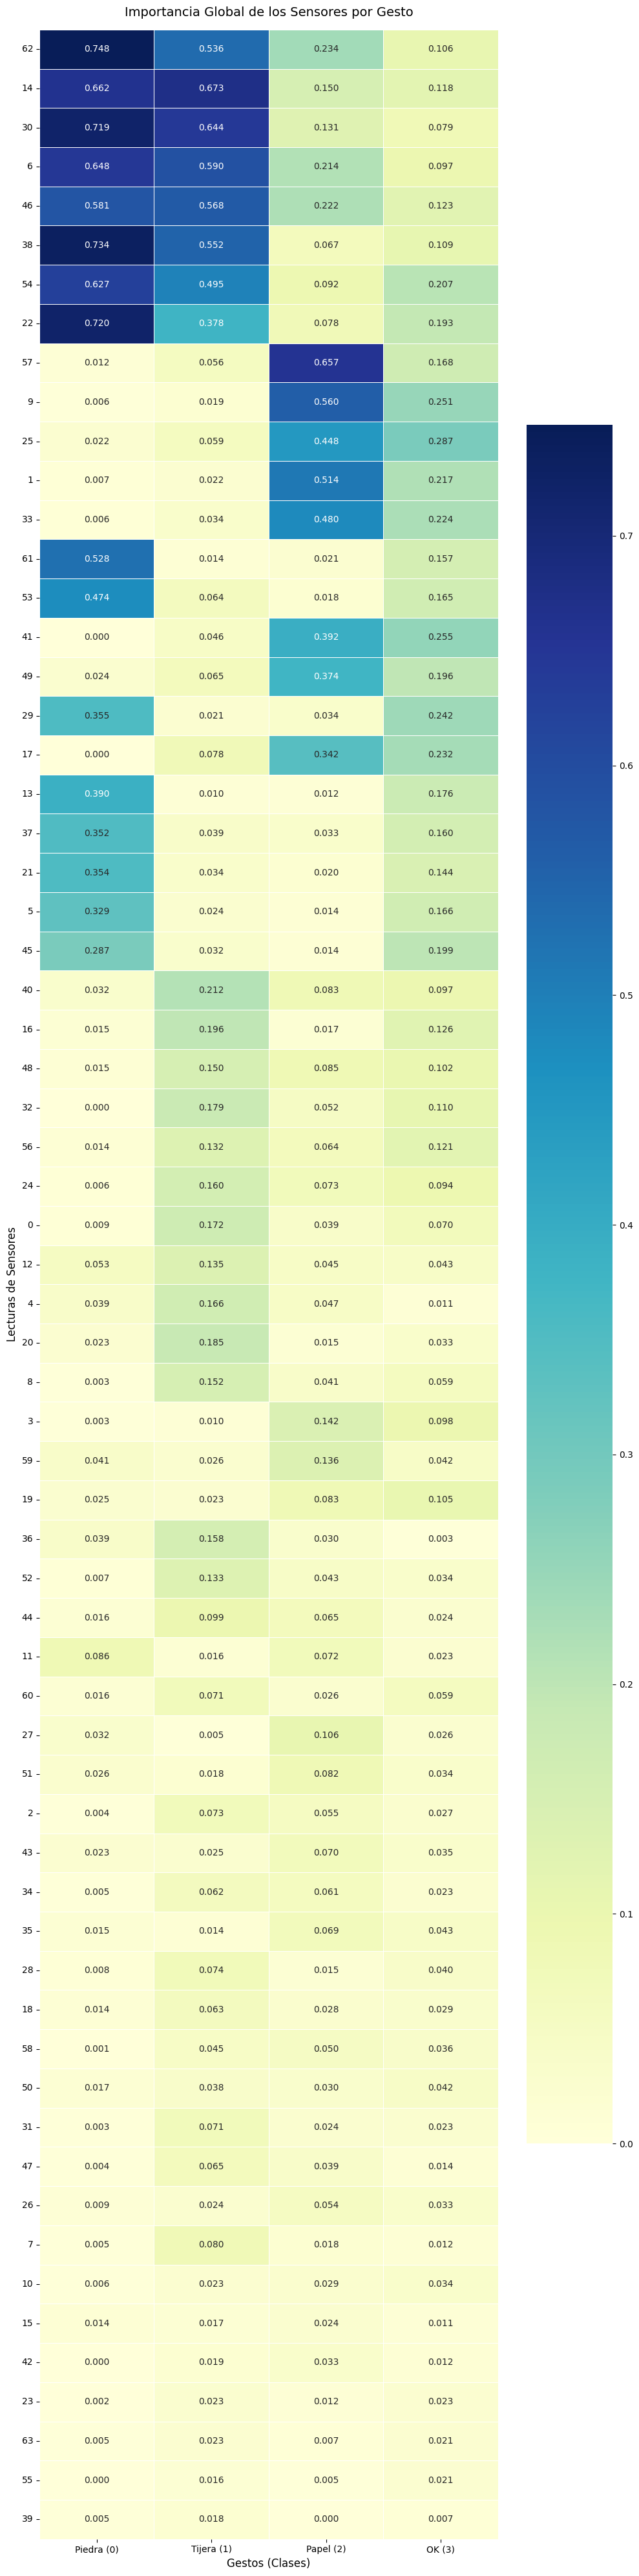

In [107]:
imp_piedra = np.abs(valores_shap[:, :, 0]).mean(axis=0)
imp_tijera = np.abs(valores_shap[:, :, 1]).mean(axis=0)
imp_papel  = np.abs(valores_shap[:, :, 2]).mean(axis=0)
imp_ok     = np.abs(valores_shap[:, :, 3]).mean(axis=0)

df_importancia = pd.DataFrame({
    'Piedra (0)': imp_piedra,
    'Tijera (1)': imp_tijera,
    'Papel (2)': imp_papel,
    'OK (3)': imp_ok
})
df_importancia['Importancia_Total'] = df_importancia.sum(axis=1)
df_top = df_importancia.sort_values(by='Importancia_Total', ascending=False)
df_top = df_top.drop(columns=['Importancia_Total'])

plt.figure(figsize=(10, 40))
sns.heatmap(df_top, cmap="YlGnBu", annot=True, fmt=".3f", linewidths=.5)

plt.title("Importancia Global de los Sensores por Gesto", fontsize=14, pad=15)
plt.ylabel("Lecturas de Sensores", fontsize=12)
plt.xlabel("Gestos (Clases)", fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [79]:
aux2=(np.array(explicacion.values))

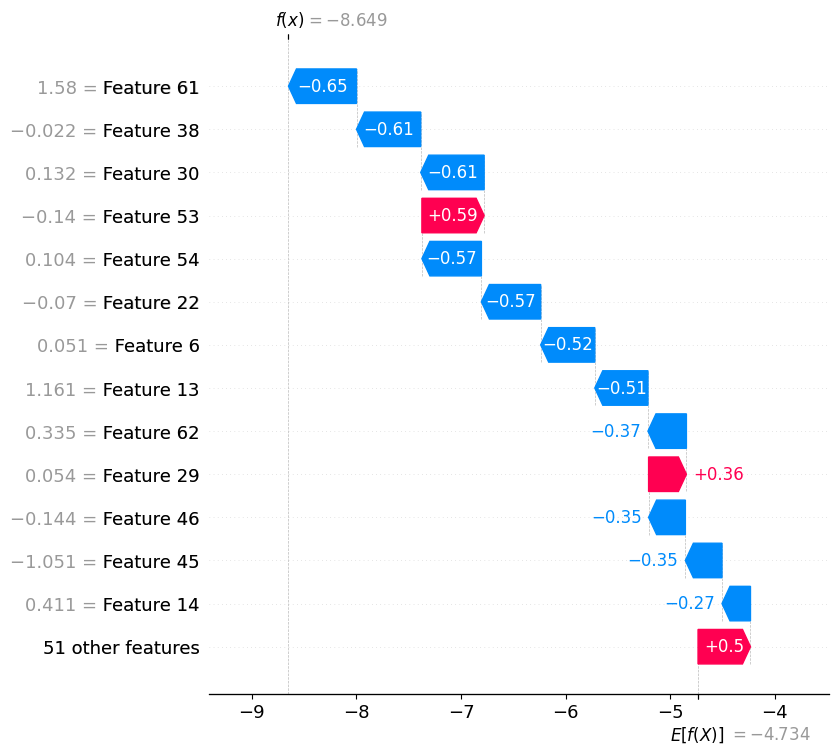

In [70]:
# (Asumiendo que ya tienes tu 'explicador' y 'X_test' del paso anterior)

# 1. Obtener el objeto 'Explanation' usando la API moderna
# IMPORTANTE: Llamamos directamente a explicador(X_test), NO a explainer.shap_values()
explicacion = explicador(X_test)

# 2. Definir qué instancia y qué clase queremos explicar
sample_ind = 2  # Índice de la fila que queremos analizar (ej. la primera lectura de X_test)
clase_ind = 0   # Índice de la clase (0=Piedra, 1=Tijera, 2=Papel, 3=OK)

# 3. Generar el gráfico Waterfall
# Pasamos la rebanada exacta tridimensional: [instancia, todos_los_sensores, clase]
shap.plots.waterfall(explicacion[sample_ind, :, clase_ind], max_display=14)